# Customer Behaviour Analysis

**Pipeline:**
1. Imports & Setup
2. Data Loading & Inspection
3. Data Preprocessing & Feature Engineering
4. Exploratory Data Analysis (EDA)
5. Sentiment Analysis (TextBlob)
6. Customer Segmentation (K-Means + PCA)
7. Segment Labelling & Insights
8. PDF Report Generation


## 1. Imports & Setup

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from fpdf import FPDF

sns.set_theme(style="whitegrid")
sns.set_palette("muted")



print("Setup complete.")


Setup complete.


## 2. Data Loading & Inspection

Load the raw customer dataset and inspect its structure, types, and missing values.


In [2]:
DATA_PATH = "../data/customers.csv"

df = pd.read_csv(DATA_PATH, parse_dates=["Last_Activity"])
print(f"Shape   : {df.shape}")
print(f"Columns : {list(df.columns)}")
df.head()


Shape   : (500, 6)
Columns : ['Customer_ID', 'Booking_Frequency', 'Avg_Spending', 'Preferred_Service', 'Review_Text', 'Last_Activity']


,Customer_ID,Booking_Frequency,Avg_Spending,Preferred_Service,Review_Text,Last_Activity
0,1001,3.0,168.99,Deep Tissue Massage,"Okay overall, some improvements needed.",2025-12-31
1,1002,14.0,NaN,Deep Tissue Massage,"Perfect stress relief, thank you!",2026-03-30
2,1003,7.0,NaN,Body Scrub,"Absolutely loved it, will book again!",2025-12-05
3,1004,2.0,77.79,Couples Massage,Expected more for the cost.,2026-03-26
4,1005,3.0,167.57,Facial,Exceeded my expectations completely.,2025-11-24


In [3]:
print("Data Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
df.describe()


Data Types:
Customer_ID                   int64
Booking_Frequency           float64
Avg_Spending                float64
Preferred_Service            object
Review_Text                  object
Last_Activity        datetime64[ns]
dtype: object

Missing Values:
Customer_ID           0
Booking_Frequency    11
Avg_Spending         15
Preferred_Service     0
Review_Text          42
Last_Activity         0
dtype: int64

Basic Statistics:


,Customer_ID,Booking_Frequency,Avg_Spending,Last_Activity
count,500.000000,489.000000,485.000000,500
mean,1250.500000,5.840491,189.017031,2026-01-11 09:44:38.399999744
min,1001.000000,1.000000,30.610000,2025-04-02 00:00:00
25%,1125.750000,2.000000,89.890000,2025-12-05 00:00:00
50%,1250.500000,5.000000,153.990000,2026-02-23 00:00:00
75%,1375.250000,8.000000,259.760000,2026-03-15 00:00:00
max,1500.000000,20.000000,597.720000,2026-04-01 00:00:00
std,144.481833,4.478445,126.217296,NaN


## 3. Data Preprocessing & Feature Engineering

Steps:
- Cast numeric columns safely with `pd.to_numeric`  
- Fill missing numeric values with the **median** (robust to skew and outliers)  
- Engineer **Days_Since_Activity** recency feature from `Last_Activity`  
- Encode `Preferred_Service` to integer for optional downstream use


In [4]:
#  3a. Safe numeric coercion 
df["Booking_Frequency"] = pd.to_numeric(df["Booking_Frequency"], errors="coerce")
df["Avg_Spending"]      = pd.to_numeric(df["Avg_Spending"],      errors="coerce")

#  3b. Median imputation for numeric columns 
for col in ["Booking_Frequency", "Avg_Spending"]:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"  {col}: filled NaN with median = {median_val:.2f}")

#  3c. Recency feature: days since last activity 
reference_date = df["Last_Activity"].max()   # most recent date in dataset
df["Days_Since_Activity"] = (reference_date - df["Last_Activity"]).dt.days
print(f"\nRecency range: {df['Days_Since_Activity'].min()} – {df['Days_Since_Activity'].max()} days")

#  3d. Fill missing Review_Text so TextBlob never errors 
df["Review_Text"] = df["Review_Text"].fillna("")

#  3e. Label-encode Preferred_Service 
le = LabelEncoder()
df["Service_Code"] = le.fit_transform(df["Preferred_Service"].fillna("Unknown"))
print(f"\nService categories: {list(le.classes_)}")

print(f"\nTotal missing values after preprocessing: {df.isnull().sum().sum()}")
df[["Booking_Frequency", "Avg_Spending", "Days_Since_Activity"]].describe()


  Booking_Frequency: filled NaN with median = 5.00
  Avg_Spending: filled NaN with median = 153.99

Recency range: 0 – 364 days

Service categories: ['Aromatherapy', 'Body Scrub', 'Couples Massage', 'Deep Tissue Massage', 'Facial', 'Hot Stone Massage', 'Manicure', 'Massage', 'Pedicure', 'Reflexology', 'Swedish Massage', 'Wellness Package']

Total missing values after preprocessing: 0


,Booking_Frequency,Avg_Spending,Days_Since_Activity
count,500.000000,500.00000,500.00000
mean,5.822000,187.96622,79.59400
std,4.430528,124.44958,95.30948
min,1.000000,30.61000,0.00000
25%,2.750000,91.55250,17.00000
50%,5.000000,153.99000,37.00000
75%,8.000000,253.76500,117.00000
max,20.000000,597.72000,364.00000


In [5]:
df.to_csv("../data/cleaned_customer_data.csv", index=False)

## 4. Exploratory Data Analysis (EDA)

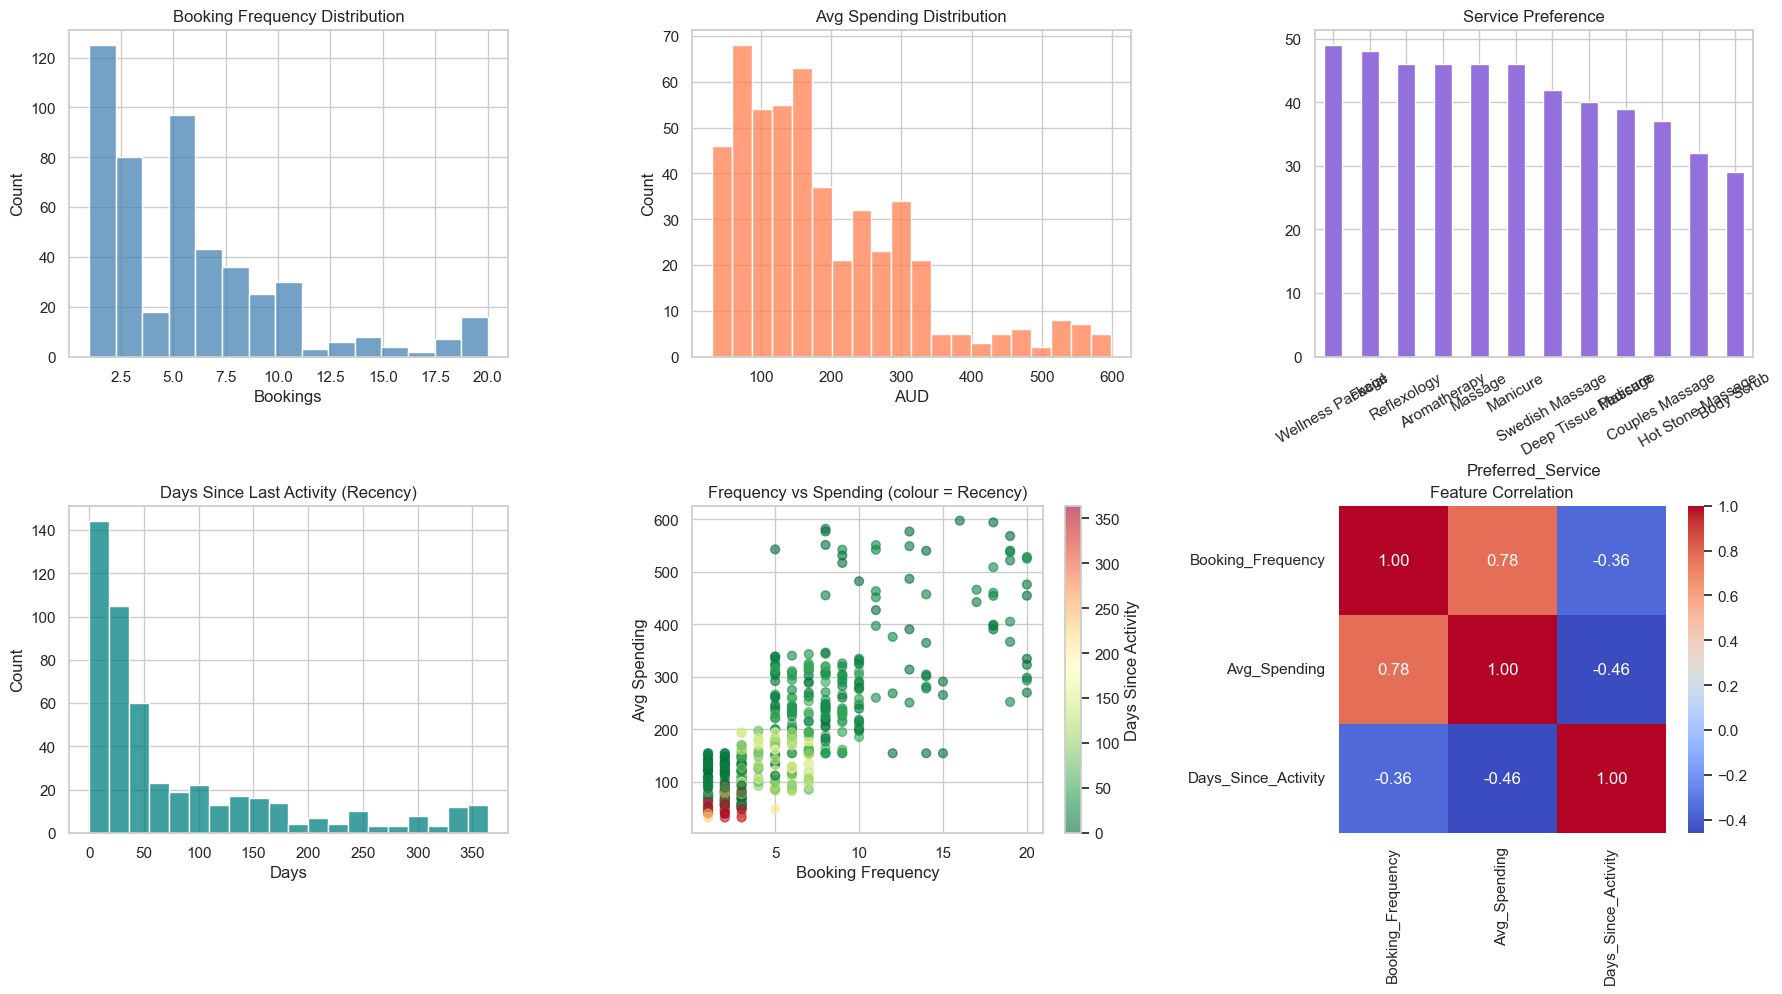

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Booking Frequency
sns.histplot(df["Booking_Frequency"], bins=15, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Booking Frequency Distribution")
axes[0, 0].set_xlabel("Bookings")

# Avg Spending
sns.histplot(df["Avg_Spending"], bins=20, ax=axes[0, 1], color="coral")
axes[0, 1].set_title("Avg Spending Distribution")
axes[0, 1].set_xlabel("AUD")

# Service Preference
service_counts = df["Preferred_Service"].value_counts()
service_counts.plot(kind="bar", ax=axes[0, 2], color="mediumpurple")
axes[0, 2].set_title("Service Preference")
axes[0, 2].tick_params(axis="x", rotation=30)

# Days Since Activity
sns.histplot(df["Days_Since_Activity"], bins=20, ax=axes[1, 0], color="teal")
axes[1, 0].set_title("Days Since Last Activity (Recency)")
axes[1, 0].set_xlabel("Days")

# Spending vs Frequency, coloured by Recency
sc = axes[1, 1].scatter(
    df["Booking_Frequency"], df["Avg_Spending"],
    c=df["Days_Since_Activity"], cmap="RdYlGn_r", alpha=0.6, s=40
)
plt.colorbar(sc, ax=axes[1, 1], label="Days Since Activity")
axes[1, 1].set_xlabel("Booking Frequency")
axes[1, 1].set_ylabel("Avg Spending")
axes[1, 1].set_title("Frequency vs Spending (colour = Recency)")

# Correlation heatmap
corr_cols = ["Booking_Frequency", "Avg_Spending", "Days_Since_Activity"]
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", ax=axes[1, 2], square=True)
axes[1, 2].set_title("Feature Correlation")

plt.tight_layout()
plt.savefig("../images/eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Sentiment Analysis (TextBlob)

TextBlob polarity scores each review on **[-1, 1]**:

| Label    | Condition          |
|----------|--------------------|
| Positive | polarity > 0.1     |
| Neutral  | -0.1 ≤ score ≤ 0.1 |
| Negative | polarity < -0.1    |


In [7]:
def classify_sentiment(score):
    if score > 0.1:  return "Positive"
    if score < -0.1: return "Negative"
    return "Neutral"

df["Sentiment_Score"] = df["Review_Text"].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)
df["Sentiment_Label"] = df["Sentiment_Score"].apply(classify_sentiment)

sentiment_counts = df["Sentiment_Label"].value_counts()
print("Sentiment Distribution:")
print(sentiment_counts)
print(f"\nMean polarity : {df['Sentiment_Score'].mean():.3f}")
print(f"Std  polarity : {df['Sentiment_Score'].std():.3f}")


Sentiment Distribution:
Sentiment_Label
Positive    296
Neutral     108
Negative     96
Name: count, dtype: int64

Mean polarity : 0.283
Std  polarity : 0.488


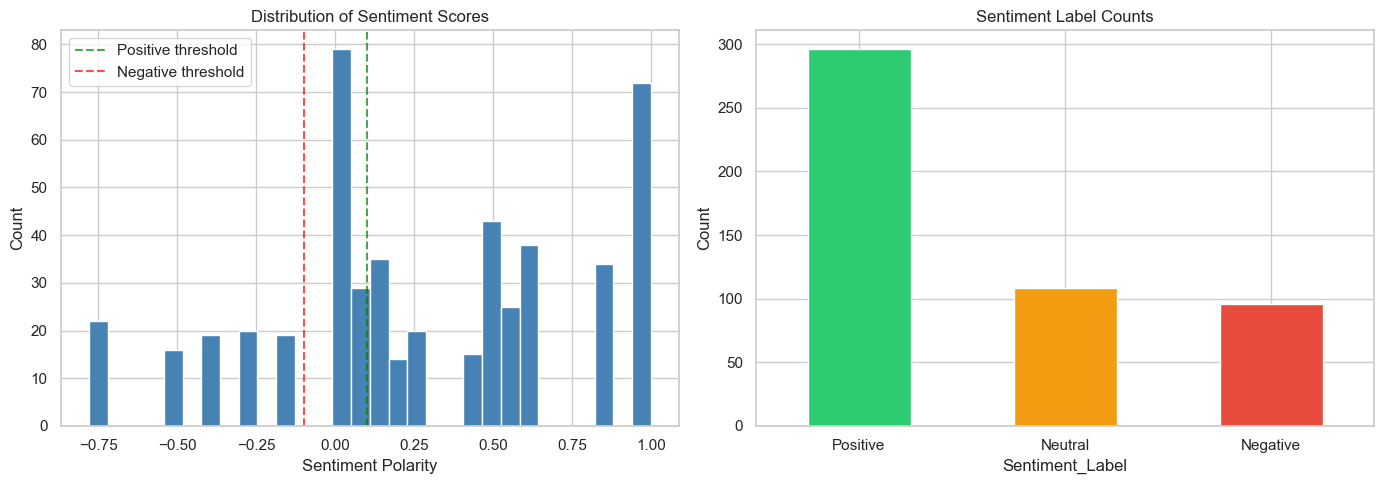

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Polarity histogram
axes[0].hist(df["Sentiment_Score"], bins=30, color="steelblue", edgecolor="white")
axes[0].axvline( 0.1, color="green", linestyle="--", alpha=0.7, label="Positive threshold")
axes[0].axvline(-0.1, color="red",   linestyle="--", alpha=0.7, label="Negative threshold")
axes[0].set_xlabel("Sentiment Polarity")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Sentiment Scores")
axes[0].legend()

# Label bar chart
colors = {"Positive": "#2ecc71", "Neutral": "#f39c12", "Negative": "#e74c3c"}
sentiment_counts.plot(
    kind="bar", ax=axes[1],
    color=[colors[l] for l in sentiment_counts.index]
)
axes[1].set_title("Sentiment Label Counts")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("../images/sentiment_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Customer Segmentation (K-Means + PCA)

**Clustering features:**
- `Booking_Frequency` — how often the customer books  
- `Avg_Spending` — average spend per booking  
- `Days_Since_Activity` — recency (lower = more recent)  
- `Sentiment_Score` — mean review polarity  

**StandardScaler** is used so high-magnitude features (spending) don't dominate clustering.


Clustering matrix: 500 customers x 4 features


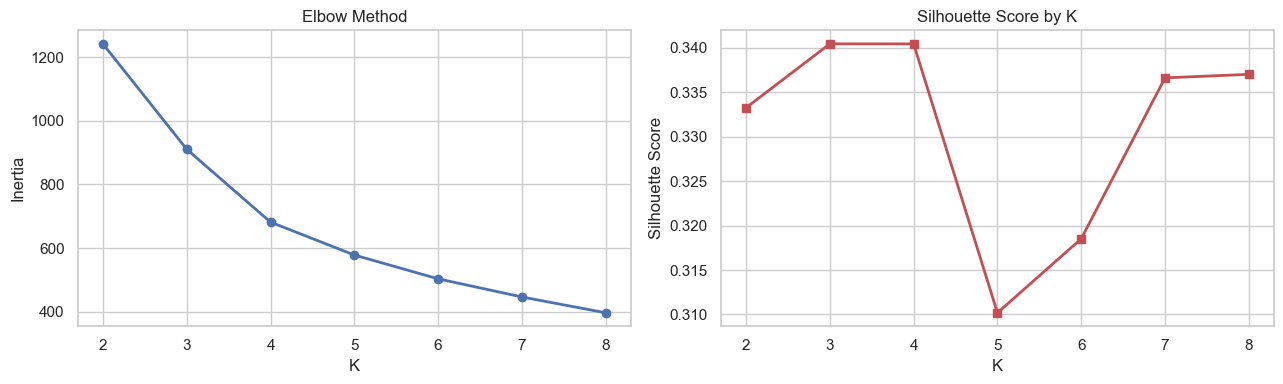

Best K = 3  (silhouette = 0.340)


In [9]:
CLUSTER_FEATURES = ["Booking_Frequency", "Avg_Spending", "Days_Since_Activity", "Sentiment_Score"]
X = df[CLUSTER_FEATURES].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Clustering matrix: {X_scaled.shape[0]} customers x {X_scaled.shape[1]} features")

# Elbow + Silhouette to choose best K 
K_range = range(2, 9)
inertias, silhouettes = [], []

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(K_range, inertias, "bo-", linewidth=2)
ax1.set_xlabel("K"); ax1.set_ylabel("Inertia"); ax1.set_title("Elbow Method")
ax1.set_xticks(list(K_range))

ax2.plot(K_range, silhouettes, "rs-", linewidth=2)
ax2.set_xlabel("K"); ax2.set_ylabel("Silhouette Score"); ax2.set_title("Silhouette Score by K")
ax2.set_xticks(list(K_range))

plt.tight_layout()
plt.savefig("../images/cluster_selection.png", dpi=150, bbox_inches="tight")
plt.show()

best_k = list(K_range)[np.argmax(silhouettes)]
print(f"Best K = {best_k}  (silhouette = {max(silhouettes):.3f})")


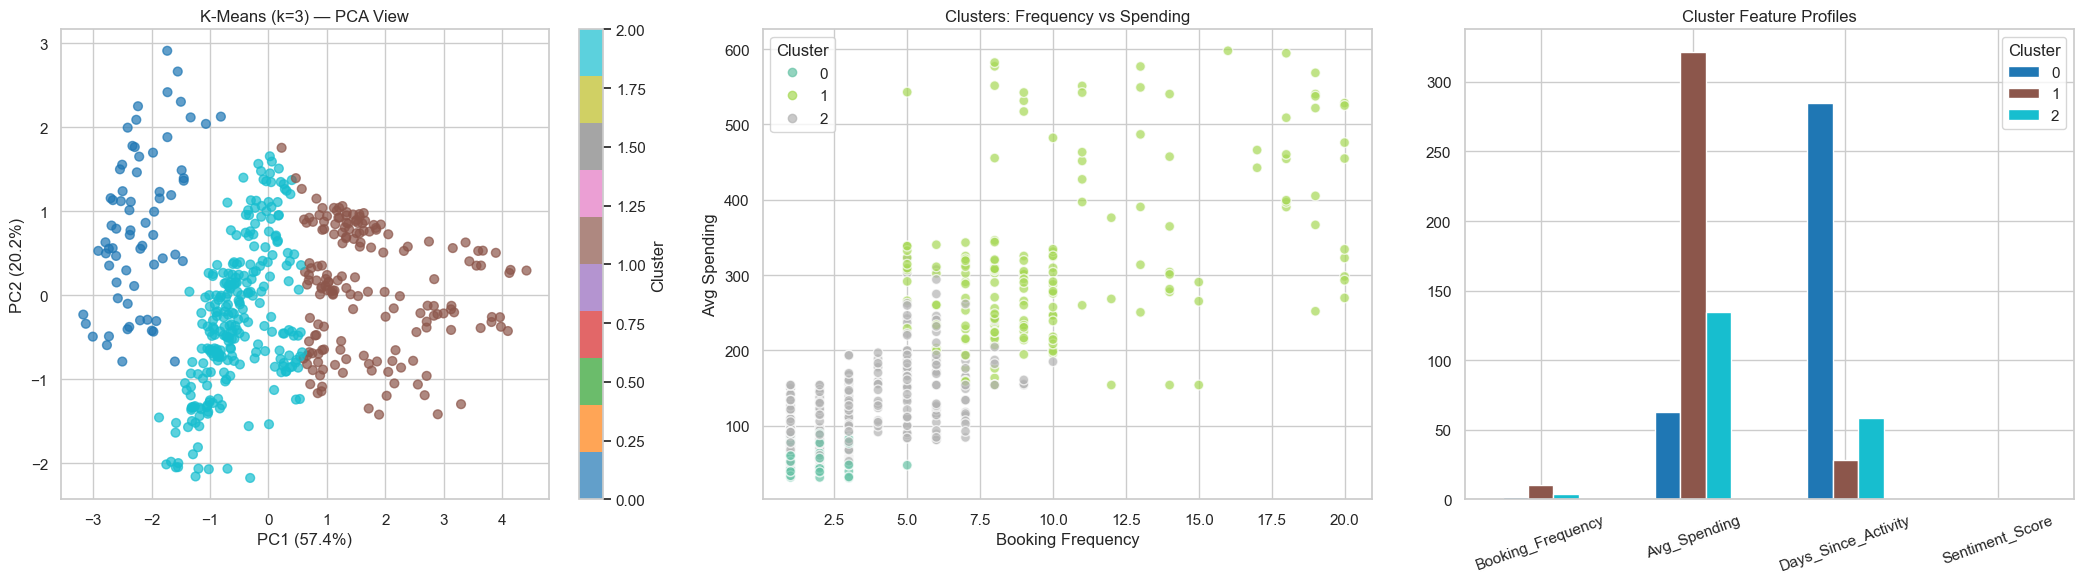

Cluster Profiles:
         Booking_Frequency  Avg_Spending  Days_Since_Activity  Sentiment_Score
Cluster                                                                       
0                     1.99         62.65               284.75             0.04
1                    10.40        321.63                28.31             0.60
2                     3.88        134.75                58.65             0.14


In [10]:
#  Fit final K-Means 
km_final = KMeans(n_clusters=best_k, n_init=10, random_state=42)
df["Cluster"] = km_final.fit_predict(X_scaled)

#  PCA for 2-D visualisation 
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
df["PC1"], df["PC2"] = coords[:, 0], coords[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# PCA scatter
sc = axes[0].scatter(df["PC1"], df["PC2"], c=df["Cluster"], cmap="tab10", alpha=0.7, s=40)
plt.colorbar(sc, ax=axes[0], label="Cluster")
axes[0].set_title(f"K-Means (k={best_k}) — PCA View")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")

# Frequency vs Spending
sc2 = axes[1].scatter(
    df["Booking_Frequency"], df["Avg_Spending"],
    c=df["Cluster"], cmap="Set2", alpha=0.7, edgecolors="w", s=50
)
axes[1].set_xlabel("Booking Frequency"); axes[1].set_ylabel("Avg Spending")
axes[1].set_title("Clusters: Frequency vs Spending")
axes[1].legend(*sc2.legend_elements(), title="Cluster")

# Feature profiles bar chart
profile = df.groupby("Cluster")[CLUSTER_FEATURES].mean().round(2)
profile.T.plot(kind="bar", ax=axes[2], colormap="tab10")
axes[2].set_title("Cluster Feature Profiles")
axes[2].tick_params(axis="x", rotation=20)
axes[2].legend(title="Cluster", loc="upper right")

plt.tight_layout()
plt.savefig("../images/cluster_visualization.png", dpi=150, bbox_inches="tight")
plt.show()

print("Cluster Profiles:")
print(profile)


## 7. Segment Labelling & Insights

In [11]:
cluster_profiles = df.groupby("Cluster").agg(
    Size             = ("Customer_ID",        "count"),
    Avg_Frequency    = ("Booking_Frequency",  "mean"),
    Avg_Spend        = ("Avg_Spending",        "mean"),
    Avg_Recency_Days = ("Days_Since_Activity", "mean"),
    Avg_Sentiment    = ("Sentiment_Score",     "mean"),
    Top_Service      = ("Preferred_Service",
                        lambda s: s.mode().iloc[0] if not s.mode().empty else "Unknown"),
).round(2)

# Auto-label clusters using data-driven quantile thresholds
freq_hi  = cluster_profiles["Avg_Frequency"].quantile(0.66)
spend_hi = cluster_profiles["Avg_Spend"].quantile(0.66)
recency_hi = cluster_profiles["Avg_Recency_Days"].quantile(0.66)
freq_lo  = cluster_profiles["Avg_Frequency"].quantile(0.33)

def label_cluster(row):
    if row["Avg_Spend"] >= spend_hi and row["Avg_Frequency"] >= freq_hi:
        return "High-Value"
    if row["Avg_Recency_Days"] >= recency_hi and row["Avg_Frequency"] <= freq_lo:
        return "At-Risk / Churn"
    return "Occasional"

cluster_profiles["Segment"] = cluster_profiles.apply(label_cluster, axis=1)
df["Segment"] = df["Cluster"].map(cluster_profiles["Segment"].to_dict())

print("Cluster Profiles with Segment Labels:")
print(cluster_profiles)
print("\nSegment Distribution:")
print(df["Segment"].value_counts())


Cluster Profiles with Segment Labels:
         Size  Avg_Frequency  Avg_Spend  Avg_Recency_Days  Avg_Sentiment  \
Cluster                                                                    
0          69           1.99      62.65            284.75           0.04   
1         169          10.40     321.63             28.31           0.60   
2         262           3.88     134.75             58.65           0.14   

         Top_Service          Segment  
Cluster                                
0        Reflexology  At-Risk / Churn  
1             Facial       High-Value  
2           Manicure       Occasional  

Segment Distribution:
Segment
Occasional         262
High-Value         169
At-Risk / Churn     69
Name: count, dtype: int64


In [12]:
high_value = df[df["Segment"] == "High-Value"]
at_risk    = df[df["Segment"] == "At-Risk / Churn"]
occasional = df[df["Segment"] == "Occasional"]

print(f"High-Value customers : {len(high_value)}")
print(f"At-Risk customers    : {len(at_risk)}")
print(f"Occasional customers : {len(occasional)}")
print()

print(" HIGH-VALUE RETENTION ")
print("  • Loyalty reward after every 5th booking")
print("  • Early access to new service launches")
print("  • Dedicated therapist / account manager preference")
print("  • Personalised thank-you and appreciation messages")
print()
print(" AT-RISK RE-ENGAGEMENT ")
print("  • 'We miss you' campaign with 15% discount voucher")
print("  • SMS / push notification within 2 weeks of inactivity")
print("  • Flexible rescheduling & refund-friendly policy")
print()
print(" OCCASIONAL UPSELL ")
print("  • Bundle offers: 3 sessions for the price of 2")
print("  • Targeted email based on preferred service")
print("  • Seasonal promotions to increase booking cadence")


High-Value customers : 169
At-Risk customers    : 69
Occasional customers : 262

 HIGH-VALUE RETENTION 
  • Loyalty reward after every 5th booking
  • Early access to new service launches
  • Dedicated therapist / account manager preference
  • Personalised thank-you and appreciation messages

 AT-RISK RE-ENGAGEMENT 
  • 'We miss you' campaign with 15% discount voucher
  • SMS / push notification within 2 weeks of inactivity
  • Flexible rescheduling & refund-friendly policy

 OCCASIONAL UPSELL 
  • Bundle offers: 3 sessions for the price of 2
  • Targeted email based on preferred service
  • Seasonal promotions to increase booking cadence
